In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
df = pd.read_csv('..\\Data\\Processed\\ai4i2020_featured.csv')

# 2. Encoding 'Product_Type'
# The dataset has 'L' (Low Quality), 'M' (Medium), 'H' (High).
# Machines with 'L' parts fail more often. We must include this.
# We map them to numbers: L=0, M=1, H=2
type_map = {'L': 0, 'M': 1, 'H': 2}
df['Type_Encoded'] = df['Product_Type'].map(type_map)

# 3. Define Features (X) and Target (y)
# Notice we DROP the cheating columns (specific failure modes)
feature_cols = [
    'Air_Temp', 'Process_Temp', 'Rotational_Speed', 'Torque', 'Tool_Wear', # Raw Sensors
    'Type_Encoded',                                                        # Metadata
    'Temp_Delta', 'Power_W', 'Risk_Heuristic'                              # Your Physics Features
]

X = df[feature_cols]
y = df['Machine_Failure']

# 4. Split Data
# stratify=y ensures we have the same % of failures in Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Shape: {X_train.shape}")
print(f"Testing Shape: {X_test.shape}")

Training Shape: (8000, 9)
Testing Shape: (2000, 9)


In [3]:
# 5. Initialize and Train
# n_estimators=100 means we build 100 decision trees
# random_state=42 ensures your results match mine
rf_model = RandomForestClassifier(n_estimators=100, 
                                  random_state=42, 
                                  class_weight='balanced') # <--- KEY PARAMETER

print("Training Model... (This might take a second)")
rf_model.fit(X_train, y_train)
print("Training Complete.")

Training Model... (This might take a second)
Training Complete.


--- Model Performance ---
Accuracy: 0.9875

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.94      0.68      0.79        68

    accuracy                           0.99      2000
   macro avg       0.96      0.84      0.89      2000
weighted avg       0.99      0.99      0.99      2000



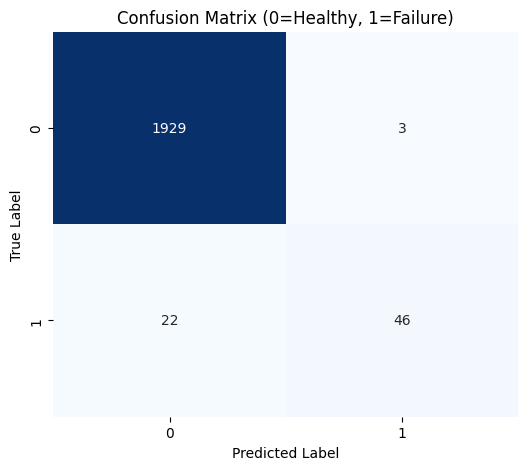

In [4]:
# 6. Make Predictions
y_pred = rf_model.predict(X_test)

# 7. The Scorecard
print("--- Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 8. Visual Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (0=Healthy, 1=Failure)')
plt.show()

Recall is quite low at 0.68, meaning we are not detecting failure when it happenes. plotting a recall vs precision trade off to find the optimal threshold.

In [5]:
# Get raw probabilities (The model's confidence)
# [:, 1] means we only care about the probability of Class 1 (Failure)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Let's look at a few "Missed" cases (False Negatives)
results = pd.DataFrame({'True_Label': y_test, 'Prob_Failure': y_prob})
print("--- failures the model missed (Prob < 0.5) ---")
print(results[(results['True_Label'] == 1) & (results['Prob_Failure'] < 0.5)].head())

--- failures the model missed (Prob < 0.5) ---
      True_Label  Prob_Failure
4851           1          0.43
7884           1          0.44
9174           1          0.00
2671           1          0.01
926            1          0.17


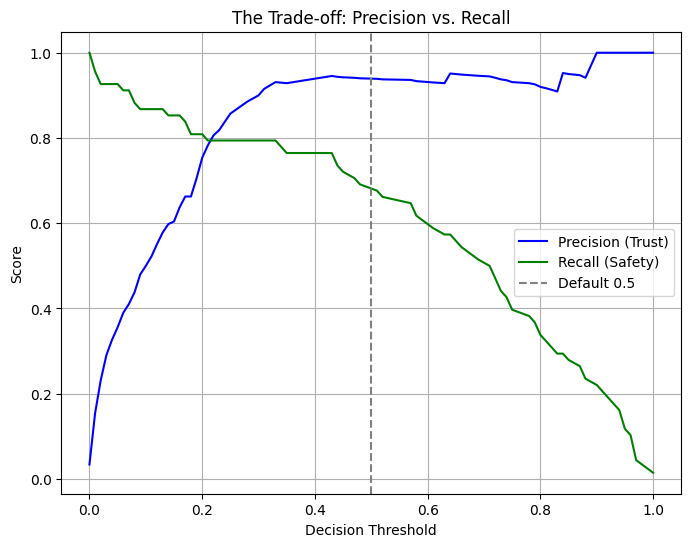

In [6]:
from sklearn.metrics import precision_recall_curve

# Calculate the trade-off
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], label='Precision (Trust)', color='blue')
plt.plot(thresholds, recall[:-1], label='Recall (Safety)', color='green')
plt.axvline(x=0.5, color='grey', linestyle='--', label='Default 0.5')

plt.title('The Trade-off: Precision vs. Recall')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid()
plt.show()


optimal threshold seems to be around 3.3 to 3.5 as both presion and recall are high

--- Performance at Threshold 0.33 ---
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.93      0.79      0.86        68

    accuracy                           0.99      2000
   macro avg       0.96      0.90      0.93      2000
weighted avg       0.99      0.99      0.99      2000



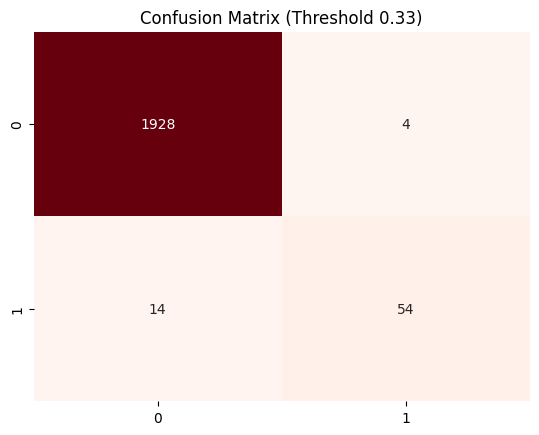

In [7]:
# Set your custom threshold (Adjust based on the chart above, e.g., 0.3)
NEW_THRESHOLD = 0.33

# Apply the new rule
y_pred_adjusted = (y_prob >= NEW_THRESHOLD).astype(int)

print(f"--- Performance at Threshold {NEW_THRESHOLD} ---")
print(classification_report(y_test, y_pred_adjusted))

# Check the new Confusion Matrix
cm = confusion_matrix(y_test, y_pred_adjusted)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title(f'Confusion Matrix (Threshold {NEW_THRESHOLD})')
plt.show()

Failure prediction is still rather low at 0.79. this is due to low data count. employing SMOTE method to mathematically generate error data using the average between 2 errors in the vector plane.

In [8]:
from imblearn.over_sampling import SMOTE

# 1. Initialize SMOTE
# sampling_strategy=1.0 means "Make the number of Failures EQUAL to Healthy"
smote = SMOTE(random_state=42, sampling_strategy=1.0)

# 2. Resample the Training Data ONLY
# (Never touch Test data - that would be cheating!)
print(f"Original Training Shape: {y_train.value_counts()}")
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"New Synthetic Training Shape: {y_train_resampled.value_counts()}")
# You should see ~7,700 Healthy and ~7,700 Failures now.

# 3. Retrain Random Forest on this massive synthetic dataset
# Note: We remove class_weight='balanced' because the data is now physically balanced!
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)

rf_smote.fit(X_train_resampled, y_train_resampled)
print("Model Retrained on Synthetic Data.")

Original Training Shape: Machine_Failure
0    7729
1     271
Name: count, dtype: int64
New Synthetic Training Shape: Machine_Failure
0    7729
1    7729
Name: count, dtype: int64
Model Retrained on Synthetic Data.


In [9]:
# 4. Predict
y_pred_smote = rf_smote.predict(X_test)

# 5. Check Recall
print("--- Performance with SMOTE ---")
print(classification_report(y_test, y_pred_smote))

# 6. Check the Probability Threshold again
y_prob_smote = rf_smote.predict_proba(X_test)[:, 1]

--- Performance with SMOTE ---
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1932
           1       0.55      0.79      0.65        68

    accuracy                           0.97      2000
   macro avg       0.77      0.89      0.82      2000
weighted avg       0.98      0.97      0.97      2000



SMOTE method are not working well. Evidently from the trade off plot the best we can do for decision forest is 0.79 recall with 0.93 precision. Try lightGBM to see if this can be further reduced.

In [10]:
import lightgbm as lgb

# 1. Setup the Data (No SMOTE - use original split)
# LightGBM handles categorical data natively, but since we already encoded Type_Encoded, we use that.

# 2. Initialize the Model
# scale_pos_weight=28 tells the model: "A failure is 28x more important than a non-failure"
# num_leaves=31 is standard.
# learning_rate=0.05 makes it learn slowly and carefully.

lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    scale_pos_weight=28,  # <--- The Magic Number
    n_jobs=-1             # Use all CPU cores
)

print("Training LightGBM...")
lgb_model.fit(X_train, y_train)
print("Training Complete.")

Training LightGBM...
[LightGBM] [Info] Number of positive: 271, number of negative: 7729
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000143 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1518
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033875 -> initscore=-3.350616
[LightGBM] [Info] Start training from score -3.350616
Training Complete.


Calculation for scale_pos_weight:
$Ratio = \frac{\text{Count(Negative)}}{\text{Count(Positive)}} \approx \frac{9661}{339} \approx 28$

--- LightGBM Performance ---
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.88      0.84      0.86        68

    accuracy                           0.99      2000
   macro avg       0.94      0.92      0.93      2000
weighted avg       0.99      0.99      0.99      2000



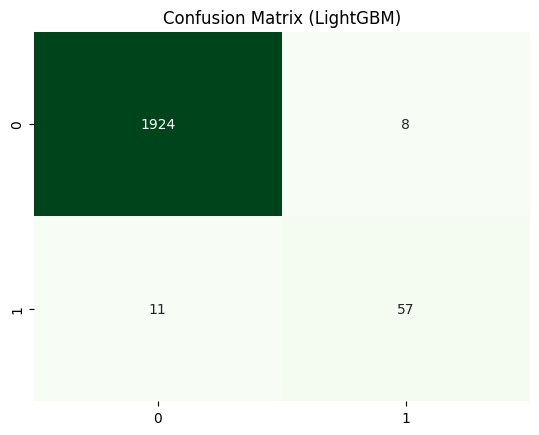

In [11]:
# 3. Predict
y_pred_lgb = lgb_model.predict(X_test)

# 4. Scorecard
print("--- LightGBM Performance ---")
print(classification_report(y_test, y_pred_lgb))

# 5. Visual Check
cm = confusion_matrix(y_test, y_pred_lgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Confusion Matrix (LightGBM)')
plt.show()

LightGBM traded precision for recall. the F1-score is the same as decision forest model at 0.86. We will favor lightGBM as the cost of false negative is a lot higher than false positive. 

In [12]:
import joblib

# 1. Define the object to save
# We bundle the model AND the feature names together.
# This ensures we never forget which column order the model expects.
artifact = {
    'model': lgb_model,
    'features': feature_cols,
    'type_map': type_map  # Save the encoding map too (L/M/H -> 0/1/2)
}

# 2. Save to file
joblib.dump(artifact, '..\\Data\\Processed\\predictive_maintenance_model.pkl')

print("Model saved successfully to 'data/processed/predictive_maintenance_model.pkl'")
print(f"Model expects these features in this order: {feature_cols}")

Model saved successfully to 'data/processed/predictive_maintenance_model.pkl'
Model expects these features in this order: ['Air_Temp', 'Process_Temp', 'Rotational_Speed', 'Torque', 'Tool_Wear', 'Type_Encoded', 'Temp_Delta', 'Power_W', 'Risk_Heuristic']
